In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import joblib
import seaborn as sns
sns.set(color_codes=True)
import matplotlib.pyplot as plt
%matplotlib inline

from numpy.random import seed
import tensorflow as tf
seed(10)
tf.random.set_seed(10)
tf.get_logger().setLevel('ERROR')
from tensorflow.keras.layers import Input, Dropout, Dense, LSTM, TimeDistributed, RepeatVector
from tensorflow.keras.models import Model
from tensorflow.keras import regularizers


✓ All imports successful!


In [ ]:
from google.colab import files
import pandas as pd
import io

uploaded = files.upload()

for filename, file_content in uploaded.items():
    file_bytes = io.StringIO(file_content.decode('utf-8'))
    dataset = pd.read_csv(file_bytes, sep=r',', header=None)
    merged_data = dataset.iloc[1:, :].values.astype(float)

Saving sensor_data (3).csv to sensor_data (3) (1).csv
Shape: (209, 3)
First 3 rows:
[[31.8 53.   0. ]
 [31.7 52.9  0. ]
 [31.7 52.9  0. ]]


In [ ]:

train = pd.DataFrame(merged_data[:150, :2], columns=['Temperature', 'Humidity'])
test_full = pd.DataFrame(merged_data[150:, :], columns=['Temperature', 'Humidity', 'Occupancy'])
test = test_full[['Temperature', 'Humidity']].copy()
y_test = test_full['Occupancy'].astype(int).values
import collections
counter = collections.Counter(y_test)
print(train.head())


Training dataset shape: (150, 2)
Test dataset shape:     (59, 2)
Test labels shape:      (59,)

Class distribution in test set:
  Normal  (0): 37
  Anomaly (1): 22

First 5 rows of training data:
   Temperature  Humidity
0         31.8      53.0
1         31.7      52.9
2         31.7      52.9
3         31.8      52.9
4         31.8      52.9


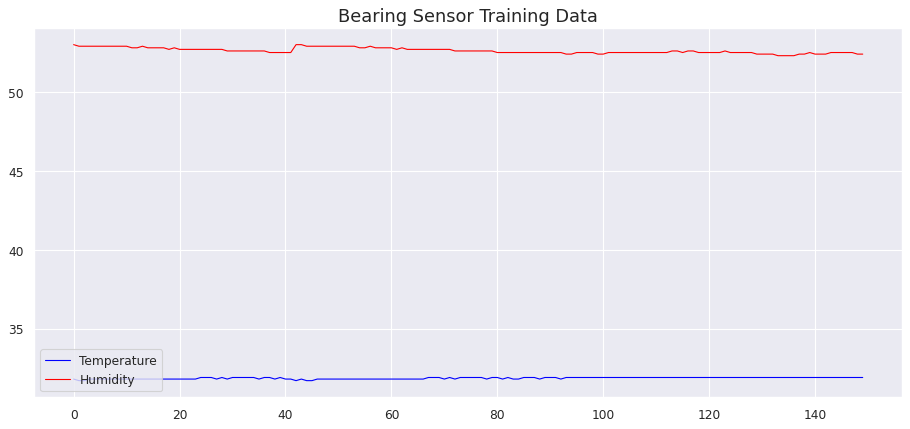

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6), dpi=80)
ax.plot(train['Temperature'], label='Temperature', color='blue', animated = True, linewidth=1)
ax.plot(train['Humidity'], label='Humidity', color='red', animated = True, linewidth=1)
plt.legend(loc='lower left')
ax.set_title('Temperature-Humidity Graph', fontsize=16)
plt.show()

In [ ]:
# normalize the data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(train)
X_test = scaler.transform(test)
scaler_filename = "scaler_data"
joblib.dump(scaler, scaler_filename)

['scaler_data']

In [ ]:

WINDOW = 30
def create_sequences(data, window):
    X = []
    for i in range(len(data) - window):
        X.append(data[i : i + window])
    return np.array(X)

X_train = create_sequences(scaler.fit_transform(train.values), WINDOW)
print("Training data shape:", X_train.shape)
X_test = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
print("Test data shape:", X_test.shape)

Training data shape: (120, 30, 2)
Test data shape: (59, 1, 2)


In [ ]:
from tensorflow.keras.layers import (
    Input, LSTM, Dense, RepeatVector,
    TimeDistributed, LayerNormalization
)
from tensorflow.keras.models import Model

def autoencoder_model(X):
    inputs = Input(shape=(X.shape[1], X.shape[2]))
    L1 = LSTM(32, return_sequences=True)(inputs)
    L1 = LayerNormalization()(L1)

    L2 = LSTM(16, return_sequences=True)(L1)
    L2 = LayerNormalization()(L2)
    L3 = LSTM(4, return_sequences=False)(L2)

    # ── Decoder ──────────────────────────────────────
    L4 = RepeatVector(X.shape[1])(L3)

    L5 = LSTM(16, return_sequences=True)(L4)
    L5 = LayerNormalization()(L5)

    L6 = LSTM(32, return_sequences=True)(L5)

    output = TimeDistributed(Dense(X.shape[2]))(L6)

    model = Model(inputs=inputs, outputs=output)
    return model

In [ ]:
# create the autoencoder model
model = autoencoder_model(X_train)
model.compile(optimizer='adam', loss='mae')
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 30, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 30, 32)         │         4,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_3           │ (None, 30, 32)         │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_16 (LSTM)                  │ (None, 30, 16)         │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_4           │ (None, 30, 16)         │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_17 (LSTM)                  │ (None, 4)              │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_3 (RepeatVector)  │ (None, 30, 4)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 30, 16)         │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_5           │ (None, 30, 16)         │            32 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 30, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 30, 2)          │            66 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,762 (61.57 KB)

 Trainable params: 15,762 (61.57 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# fit the model to the data
nb_epochs = 50
batch_size = 10
history = model.fit(X_train, X_train, epochs=nb_epochs, batch_size=batch_size,
                    validation_split=0.05).history

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/step - loss: 0.3593 - val_loss: 0.1212
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.2038 - val_loss: 0.1242
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.1570 - val_loss: 0.1043
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.1460 - val_loss: 0.0977
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - loss: 0.1394 - val_loss: 0.0813
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.1346 - val_loss: 0.0783
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - loss: 0.1314 - val_loss: 0.0744
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 0.1278 - val_loss: 0.0776
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 0.1256 - val_loss: 0.0789
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.1237 - val_loss: 0.0724
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 0.1221 - val_loss: 0.0715
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - loss: 0

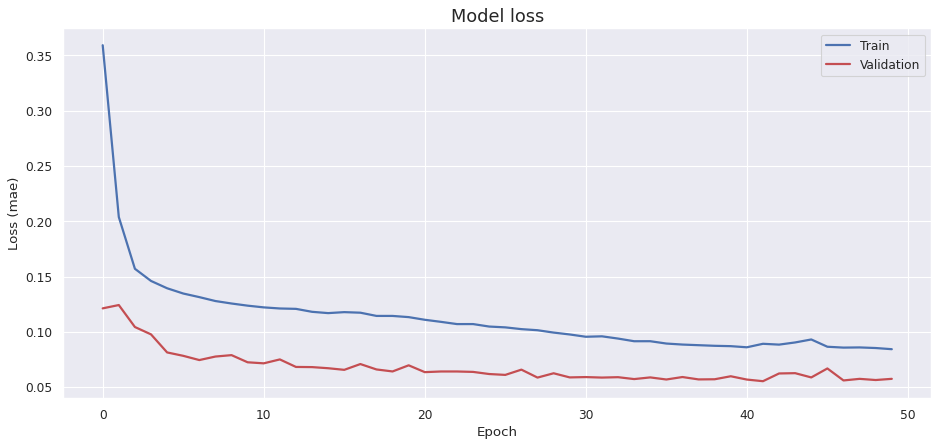

In [ ]:
# plot the training losses
fig, ax = plt.subplots(figsize=(14, 6), dpi=80)
ax.plot(history['loss'], 'b', label='Train', linewidth=2)
ax.plot(history['val_loss'], 'r', label='Validation', linewidth=2)
ax.set_title('Model loss', fontsize=16)
ax.set_ylabel('Loss (mae)')
ax.set_xlabel('Epoch')
ax.legend(loc='upper right')
plt.show()

In [ ]:
X_pred = model.predict(X_test)
loss_per_step = np.abs(X_pred - X_test)
loss_mae = np.mean(loss_per_step, axis=(1, 2))
scored = pd.DataFrame(index=range(len(loss_mae)))
scored['Loss_mae'] = loss_mae
scored['Threshold'] = 0.350
scored['Anomaly'] = scored['Loss_mae'] > scored['Threshold']
scored['Actual_Anomaly'] = y_test.astype(bool)

# No need for DataFrames if you just need the loss
print(scored.head())

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
   Loss_mae  Threshold  Anomaly  Actual_Anomaly
0  0.350142      0.275     True           False
1  1.729413      0.275     True           False
2  3.107877      0.275     True            True
3  4.568341      0.275     True            True
4  5.565848      0.275     True            True


In [ ]:
X_pred = model.predict(X_test)
loss_per_step = np.abs(X_pred - X_test)
loss_mae = np.mean(loss_per_step, axis=(1, 2))
scored = pd.DataFrame(index=range(len(loss_mae)))
scored['Loss_mae'] = loss_mae
scored['Threshold'] = 0.350
scored['Anomaly'] = scored['Loss_mae'] > scored['Threshold']
if len(y_test) != len(loss_mae):
    print(f"⚠️ Length mismatch: y_test={len(y_test)}, loss_mae={len(loss_mae)}")
    print(f"Truncating to {len(loss_mae)} samples")
    y_test_aligned = y_test[:len(loss_mae)]
else:
    y_test_aligned = y_test

scored['Actual_Anomaly'] = y_test_aligned.astype(bool)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score
)

y_pred = scored['Anomaly'].astype(int).values
y_true = y_test_aligned

print("═" * 55)
print("         MODEL EVALUATION ON TEST SET")
print("═" * 55)

acc = accuracy_score(y_true, y_pred)
print(f"\n✅ Accuracy  : {acc * 100:.2f}%")
print(scored)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
═══════════════════════════════════════════════════════
         MODEL EVALUATION ON TEST SET
═══════════════════════════════════════════════════════

✅ Accuracy  : 37.29%
     Loss_mae  Threshold  Anomaly  Actual_Anomaly
0    0.350142        0.3     True           False
1    1.729413        0.3     True           False
2    3.107877        0.3     True            True
3    4.568341        0.3     True            True
4    5.565848        0.3     True            True
5    6.983592        0.3     True            True
6    7.989880        0.3     True            True
7    7.300576        0.3     True            True
8    6.219038        0.3     True            True
9    5.536842        0.3     True            True
10   4.900615        0.3     True           False
11   4.241467        0.3     True           False
12   3.550868        0.3     True           False
13   3.124184        0.3     True            True
14   3.799771        0.3     True      

     Loss_mae  Threshold  Anomaly  Actual_Anomaly
0    0.350142        0.3     True           False
1    1.729413        0.3     True           False
2    3.107877        0.3     True            True
3    4.568341        0.3     True            True
4    5.565848        0.3     True            True
5    6.983592        0.3     True            True
6    7.989880        0.3     True            True
7    7.300576        0.3     True            True
8    6.219038        0.3     True            True
9    5.536842        0.3     True            True
10   4.900615        0.3     True           False
11   4.241467        0.3     True           False
12   3.550868        0.3     True           False
13   3.124184        0.3     True            True
14   3.799771        0.3     True            True
15   4.554354        0.3     True            True
16   5.434309        0.3     True            True
17   6.479957        0.3     True            True
18   7.343550        0.3     True            True


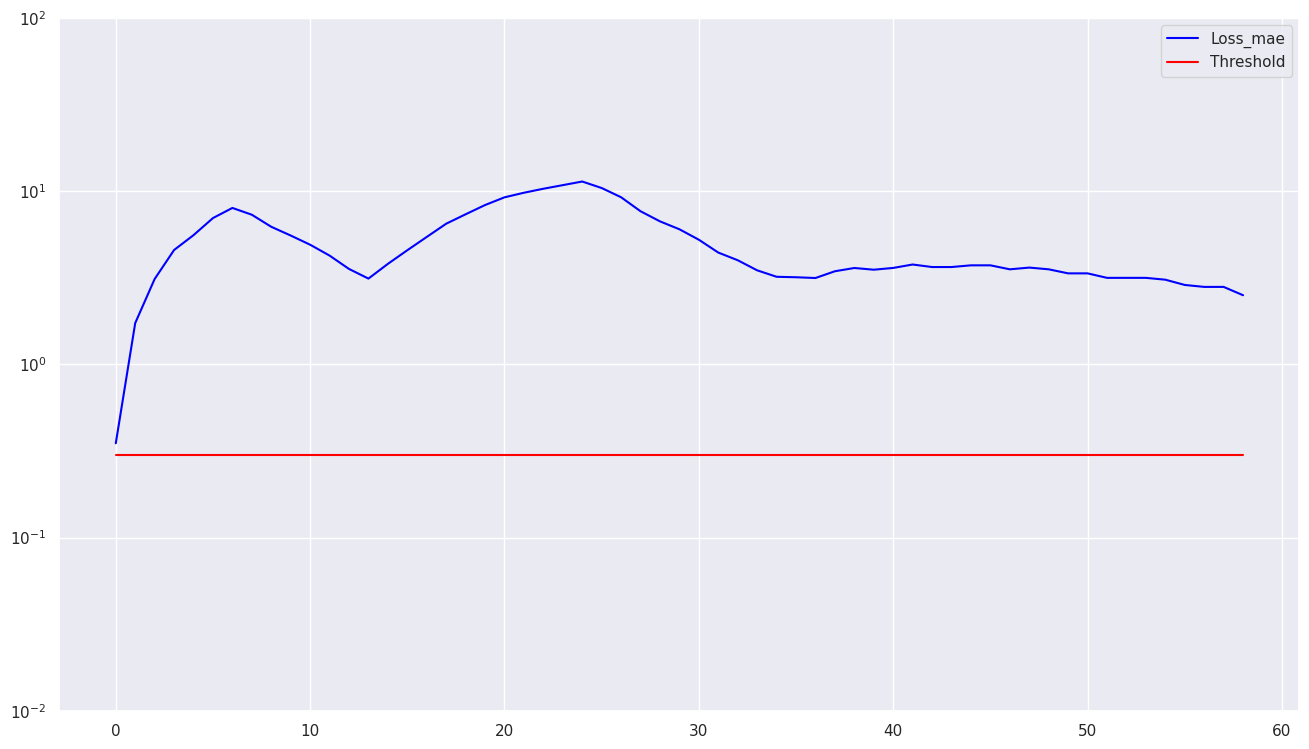

In [ ]:
# plot bearing failure time plot
scored.plot(logy=True,  figsize=(16,9), ylim=[1e-2,1e2], color=['blue','red'])


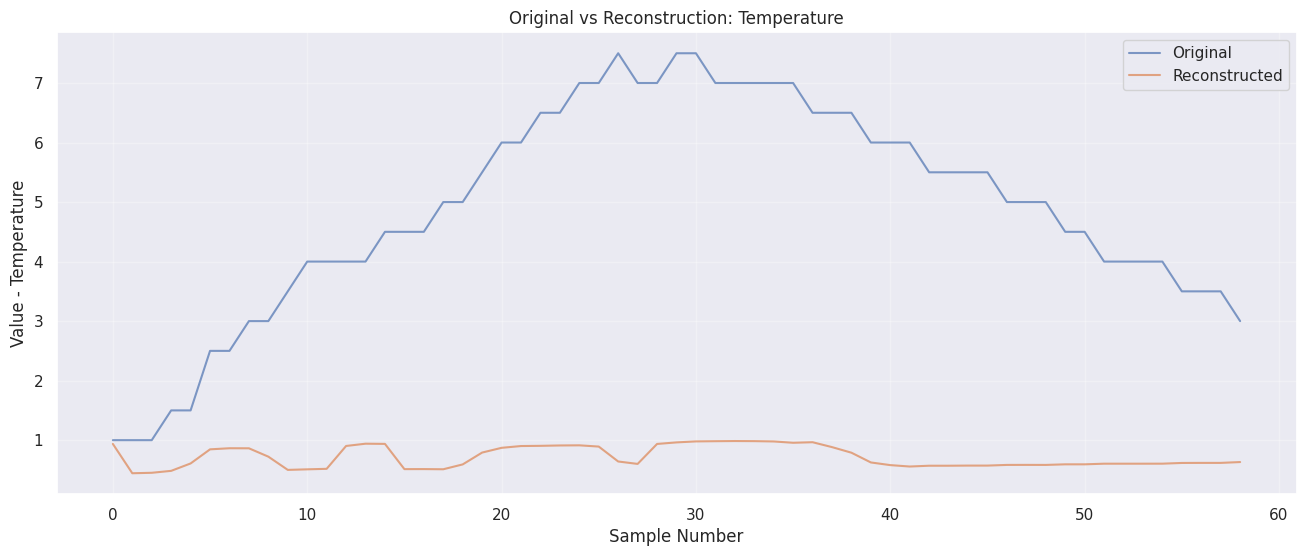

In [ ]:
import matplotlib.pyplot as plt
feature_index = 0
feature_name = test.columns[feature_index]
original = X_test[:, -1, feature_index]
reconstructed = X_pred[:, -1, feature_index]
plt.figure(figsize=(16, 6))
plt.plot(original, label='Original', alpha=0.7)
plt.plot(reconstructed, label='Reconstructed', alpha=0.7)
plt.xlabel('Sample Number')
plt.ylabel(f'Value - {feature_name}')
plt.title(f'Original vs Reconstruction: {feature_name}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# save all model information, including weights, in h5 format
model.save("Cloud_model.h5")
print("Model saved")